In [53]:
# Stochastic Volatility Model with Predictions

# Imports & Settings
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
import seaborn as sns

import pymc as pm
import arviz as az

sns.set_style('whitegrid')

## Load and Prepare Data

# Load QQQ data
prices = pd.read_hdf('../data/assets.h5', key='stooq/us/nasdaq/etfs/prices').loc[['QQQ.US'], 'close'].droplevel('ticker')
log_returns = np.log(prices).diff().dropna()

# Split data into train and test sets (using last year as test)
train_data = log_returns[:-252]  # All but last year
test_data = log_returns[-252:]   # Last year

print(f"Training data shape: {train_data.shape}")
print(f"Test data shape: {test_data.shape}")

## Define and Fit Model

def build_sv_model(returns):
    """Build stochastic volatility model for given returns data"""
    
    with pm.Model() as model:
        returns_data = pm.MutableData('returns_data', returns)
        n_obs = returns_data.shape[0]  # Dynamic shape
        
        # Priors
        step_size = pm.Exponential('sigma', 50.)
        s = pm.GaussianRandomWalk('s', sigma=step_size, shape=n_obs)
        nu = pm.Exponential('nu', .1)
        
        # Likelihood
        r = pm.StudentT('r', nu=nu, 
                       lam=pm.math.exp(-2*s), 
                       observed=returns_data)
    return model

# Build and fit model on training data
model = build_sv_model(train_data)

with model:
    trace = pm.sample(tune=2000, 
                     draws=5000,
                     chains=4,
                     cores=1,
                     target_accept=.9,
                     progressbar=True,
                     nuts_sampler='nutpie')

Training data shape: (4778,)
Test data shape: (252,)


Progress,Draws,Divergences,Step Size,Gradients/Draw
,7000,0,0.06,511
,7000,0,0.06,511
,7000,0,0.05,511
,7000,0,0.06,511


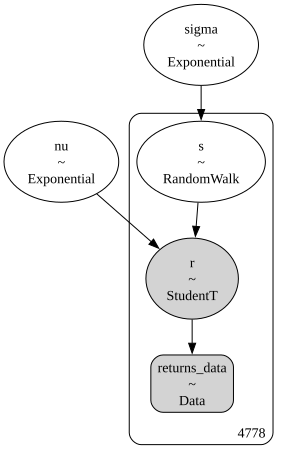

In [75]:
pm.model_to_graphviz(model)

array([[<Axes: title={'center': 'sigma'}>,
        <Axes: title={'center': 'sigma'}>],
       [<Axes: title={'center': 'nu'}>, <Axes: title={'center': 'nu'}>]],
      dtype=object)

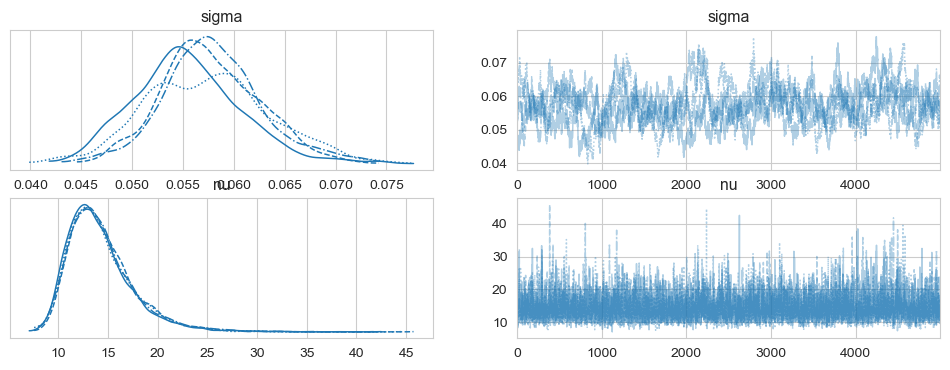

In [ ]:
az.plot_trace(trace, var_names=['sigma', 'nu']);

In [76]:
## Make Predictions
# Function to make predictions on test data
def predict_volatility(model, trace, test_data):
    """Make predictions for test data using the fitted model"""

    with model:
        pm.set_data({'returns_data': test_data})
        ppc = pm.sample_posterior_predictive(trace, var_names=['sigma', 'nu', 's'])
        
        return ppc

# Generate predictions
ppc = predict_volatility(model, trace, train_data)


Sampling: [nu, s, sigma]


In [87]:
def manual_sv_posterior_predictive(trace, n_samples=100):
    # Use actual fitted sigma values
    sigma_samples = trace.posterior.sigma.values.flatten()
    nu_samples = trace.posterior.nu.values.flatten()
    n_obs = len(train_data)
    
    results = {'s': [], 'r': []}
    
    for i in range(n_samples):
        # Use fitted parameters
        sigma_val = sigma_samples[i % len(sigma_samples)]
        nu_val = nu_samples[i % len(nu_samples)]
        
        # Generate new random walk with fitted sigma
        innovations = np.random.normal(0, sigma_val, n_obs)
        s_path = np.cumsum(innovations)
        
        # Generate returns with fitted nu and new volatility
        lam = np.exp(-2 * s_path)
        r_path = np.random.standard_t(nu_val, n_obs) / np.sqrt(lam)
        
        results['s'].append(s_path)
        results['r'].append(r_path)
    
    return {k: np.array(v) for k, v in results.items()}

manual_ppc = manual_sv_posterior_predictive(trace, 252)
print(f"Manual s std: {manual_ppc['s'].std():.4f}")

Manual s std: 2.7599


In [90]:
manual_ppc['s'].shape

(252, 4778)

In [92]:
ppc.posterior_predictive.s.shape

(4, 5000, 4778)

In [ ]:
fig, ax = plt.subplots(figsize=(15, 5))

test_data.plot(ax=ax, lw=.5, xlim=('2019', '2020'), rot=0,
                 title='Out of Sample Fit of Stochastic Volatility Model')

# Get posterior samples for s and reshape to match the plotting needs
s_samples = ppc.posterior_predictive.s.values  # shape: (chain, draw, time)
s_samples = s_samples.reshape(-1, s_samples.shape[-1])  # reshape to (chain*draw, time)

# Plot each sample path
ax.plot(test_data.index, np.exp(s_samples.T), 'r', alpha=.03, lw=.5)

ax.set(xlabel='Time', ylabel='Returns')
ax.legend(['QQQ (log returns)', 'Stochastic Volatility Model'])
ax.yaxis.set_major_formatter(FuncFormatter(lambda y, _: '{:.0%}'.format(y)))

sns.despine()
fig.tight_layout()


In [ ]:
## Evaluate Predictions

def evaluate_predictions(actual_returns, predicted_vol):
    """Calculate basic evaluation metrics"""
    # Calculate realized volatility (using rolling window)
    realized_vol = actual_returns.rolling(window=21).std()
    
    # Calculate metrics
    mse = np.mean((realized_vol - predicted_vol)**2)
    mae = np.mean(np.abs(realized_vol - predicted_vol))
    
    print(f"Mean Squared Error: {mse:.6f}")
    print(f"Mean Absolute Error: {mae:.6f}")
    
    return mse, mae

# Evaluate predictions
mse, mae = evaluate_predictions(test_data, predicted_vol)

In [ ]:
from typing import Tuple, List, Dict
from scipy.stats import spearmanr

def create_time_series_splits(data: pd.Series, 
                            train_size: int = 252,  # 1 year of trading days
                            test_size: int = 21,    # 1 month of trading days
                            step_size: int = 21) -> List[Tuple[pd.Series, pd.Series]]:
    """
    Create time series cross-validation splits using a rolling window approach.
    
    Args:
        data: Time series data
        train_size: Size of training window in days
        test_size: Size of test window in days
        step_size: Number of days to move forward for each split
        
    Returns:
        List of (train, test) splits
    """
    splits = []
    n_splits = (len(data) - train_size - test_size) // step_size + 1
    
    for i in range(n_splits):
        train_start = i * step_size
        train_end = train_start + train_size
        test_end = train_end + test_size
        
        train_data = data.iloc[train_start:train_end]
        test_data = data.iloc[train_end:test_end]
        
        splits.append((train_data, test_data))
    
    return splits

def run_cross_validation(data: pd.Series,
                        build_model_fn,
                        predict_fn,
                        train_size: int = 252,
                        test_size: int = 21,
                        step_size: int = 21) -> Dict:
    """
    Run time series cross-validation for the stochastic volatility model.
    
    Args:
        data: Time series data
        build_model_fn: Function to build the model
        predict_fn: Function to make predictions
        train_size: Size of training window
        test_size: Size of test window
        step_size: Step size for rolling window
        
    Returns:
        Dictionary containing predictions and metrics
    """
    splits = create_time_series_splits(data, train_size, test_size, step_size)
    
    all_predictions = []
    all_actuals = []
    metrics = []
    
    for i, (train_data, test_data) in enumerate(splits):
        # Build and fit model
        model = build_model_fn(train_data)
        with model:
            trace = pm.sample(tune=2000, 
                            draws=5000,
                            chains=4,
                            cores=1,
                            target_accept=.9,
                            progressbar=True,
                            nuts_sampler='nutpie')
        
        # Make predictions
        predicted_vol = predict_fn(model, trace, test_data)
        
        # Calculate realized volatility
        realized_vol = test_data.rolling(window=21).std()
        
        # Store predictions and actuals
        all_predictions.extend(predicted_vol)
        all_actuals.extend(realized_vol)
        
        # Calculate metrics for this split
        split_metrics = {
            'split': i,
            'mse': np.mean((realized_vol - predicted_vol)**2),
            'mae': np.mean(np.abs(realized_vol - predicted_vol)),
            'ic': spearmanr(realized_vol, predicted_vol)[0]
        }
        metrics.append(split_metrics)
    
    # Aggregate results
    results = {
        'predictions': pd.Series(all_predictions, index=data.index[train_size:]),
        'actuals': pd.Series(all_actuals, index=data.index[train_size:]),
        'metrics': pd.DataFrame(metrics)
    }
    
    return results

def plot_cv_results(results: Dict):
    """
    Plot cross-validation results.
    
    Args:
        results: Dictionary containing predictions and metrics
    """
    # Plot predictions vs actuals
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 10))
    
    # Plot 1: Predictions vs Actuals
    results['predictions'].plot(ax=ax1, label='Predicted Volatility', alpha=0.7)
    results['actuals'].plot(ax=ax1, label='Realized Volatility', alpha=0.7)
    ax1.set_title('Predicted vs Realized Volatility')
    ax1.legend()
    
    # Plot 2: Rolling Metrics
    results['metrics'].set_index('split').plot(ax=ax2)
    ax2.set_title('Cross-Validation Metrics by Split')
    
    plt.tight_layout()
    return fig

def evaluate_cv_results(results: Dict) -> Dict:
    """
    Calculate overall evaluation metrics for cross-validation results.
    
    Args:
        results: Dictionary containing predictions and metrics
        
    Returns:
        Dictionary of overall metrics
    """
    overall_metrics = {
        'overall_mse': np.mean((results['actuals'] - results['predictions'])**2),
        'overall_mae': np.mean(np.abs(results['actuals'] - results['predictions'])),
        'overall_ic': spearmanr(results['actuals'], results['predictions'])[0],
        'mean_split_mse': results['metrics']['mse'].mean(),
        'mean_split_mae': results['metrics']['mae'].mean(),
        'mean_split_ic': results['metrics']['ic'].mean()
    }
    
    return overall_metrics

In [ ]:
# Run cross-validation
cv_results = run_cross_validation(
    data=log_returns,
    build_model_fn=build_sv_model,
    predict_fn=predict_volatility,
    train_size=252,  # 1 year
    test_size=21,    # 1 month
    step_size=21     # Move forward 1 month at a time
)

# Plot results
plot_cv_results(cv_results)

# Get overall metrics
metrics = evaluate_cv_results(cv_results)
print("Overall Cross-Validation Metrics:")
for metric, value in metrics.items():
    print(f"{metric}: {value:.4f}")